# CXCR4 ligands - dataset from ChEMBL
- CXCR4 - chemokine receptor
- IC50 = the concentration of a drug that is required to inhibit the receptor by 50% in vitro

### Original dataset

In [1]:
import pandas as pd

df = pd.read_csv("CXCR4_chembl_ligands.csv", sep=";")
df = df[["Smiles", "Assay Type", "Molecule Name", "Molecular Weight", "AlogP", "#RO5 Violations", "Standard Type", "Standard Relation", "Standard Value", "Standard Units"]]
df.head(5)

,Smiles,Assay Type,Molecule Name,Molecular Weight,AlogP,#RO5 Violations,Standard Type,Standard Relation,Standard Value,Standard Units
0,CCCCN1C(=O)C(CC(C)C)NC(=O)C12CCN(Cc1ccc(Oc3ccc...,B,NaN,514.11,4.99,0.0,IC50,'>',10000.0,nM
1,N=C(N)NCCCN[C@H]1CSSC[C@H](C(=O)NCCc2ccc(O)cc2...,B,NaN,794.02,0.18,2.0,IC50,'=',1000.0,nM
2,N=C(N)NCCC(=O)N[C@H]1CC/C=C\CC[C@H](C(N)=O)NC(...,B,NaN,677.81,-1.14,2.0,IC50,'=',10000.0,nM
3,NCCCCN(Cc1nc2ccccc2[nH]1)[C@H]1CCCc2cccnc21,B,MAVORIXAFOR,349.48,3.58,0.0,IC50,'=',30.0,nM
4,NCCCCN(C[C@H]1Cc2ccccc2CN1CC(=O)N1CCOCC1)[C@H]...,F,NaN,491.68,2.79,0.0,IC50,'=',570.0,nM


In [7]:
print("-------------\nDataset before filtering:\n-------------")
print(df.shape)
print(df["Standard Type"].value_counts())
print(df["Standard Relation"].value_counts())
print(df["Standard Units"].value_counts())

-------------
Dataset before filtering:
-------------
(1550, 10)
Standard Type
IC50    1550
Name: count, dtype: int64
Standard Relation
'='    1210
'>'     303
'<'       6
Name: count, dtype: int64
Standard Units
nM         1492
ug.mL-1      45
Name: count, dtype: int64


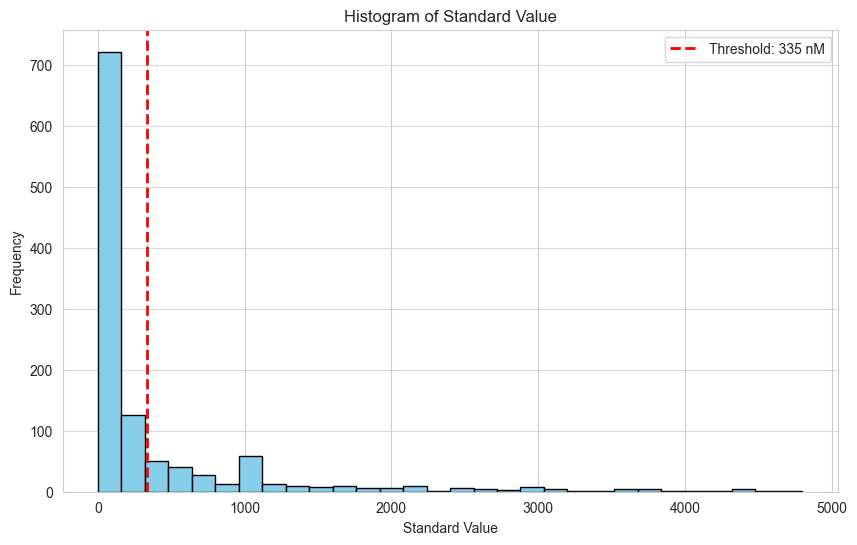

In [3]:
from plotter import plot_column_histogram
filtered = df[df['Standard Type'] == "IC50"]
plot_column_histogram(filtered[filtered['Standard Value'] < 5000], "Standard Value", threshold=335)

### Dataset filtering
- consider only IC50 (since Ki and EC50 are poorly represented)
- remove duplicates (either delete or keep average)
- new column "Inhibitor" (0/1) - active/inactive based on balanced dataset
- threshold about 200 nM - which is relevant according to Gemini:
    - "In CXCR4 drug discovery, the gold standard for a "potent" lead compound is usually $< 100\text{ nM}$, while anything $> 1,000\text{ nM}$ ($1\text{ }\mu\text{M}$) is often considered weak or inactive."

In [2]:
from source import create_balanced_cxcr4_dataset
df = df[df['Standard Type'] == "IC50"]
df_ready = create_balanced_cxcr4_dataset(df, id_col="Smiles", margin_percent=0.15)
df_ready.head(10)

----------------------------------------
CONSISTENCY & DUPLICATE ANALYSIS
----------------------------------------
Initial number of rows: 1519
Compounds averaged (diff <= 1 log unit): 102
Compounds deleted  (diff > 1 log unit):  62
Rows remaining after cleanup:      1127
----------------------------------------
FINAL DATASET SUMMARY
----------------------------------------
Active Range:      0.40 - 167.00 nM
Inactive Range:    502.00 - 225000.00 nM
Clearance Gap:     335.00 nM
Dropped Margin:    128 rows
Balanced Classes:  499 Actives / 499 Inactives
----------------------------------------


,Assay Type,Molecule Name,Molecular Weight,AlogP,#RO5 Violations,Standard Type,Standard Relation,Standard Value,Standard Units,Original Smiles,nM,Inhibitor
0,F,NaN,554.74,4.84,1.0,IC50,=,123.0,nM,C[C@@H]1CN(C(=O)Cn2c3ccccc3c3ccnc(CN(CCCCN)[C@...,123.0,1
1,B,NaN,428.58,3.79,0.0,IC50,>,7.0,nM,CN(CCc1ccccc1)C[C@@H]1CCN(CCc2c[nH]c3ccc(-n4cn...,7.0,0
2,B,NaN,644.73,-0.32,2.0,IC50,=,63.0,nM,C[C@@H]1NC(=O)[C@H](CCCNC(=N)N)NC(=O)[C@H](Cc2...,63.0,1
3,F,NaN,404.60,3.87,0.0,IC50,=,161.0,nM,c1ccc2c(c1)CN[C@@H](CN(CC[C@@H]1CCCNC1)[C@H]1C...,161.0,1
4,F,NaN,464.57,6.43,1.0,IC50,>,3000.0,nM,CCCCN(c1nc2ccccc2o1)C(c1ccc(-c2ccccc2-c2nnn[nH...,3000.0,0
5,B,NaN,888.04,1.89,2.0,IC50,=,10000.0,nM,CN1C(=O)[C@H](CCCNC(=N)N)NC(=O)[C@@H](Cc2ccc(O...,10000.0,0
6,B,NaN,595.74,6.97,2.0,IC50,>,1000.0,nM,C=CCN(C(=O)OCc1ccc([N+](=O)[O-])cc1)C1CCN(CCC(...,1000.0,0
7,B,NaN,430.69,5.23,1.0,IC50,=,1873.0,nM,C1=C(CS/C(=N\C2CCCCC2)NC23CC4CC(CC(C4)C2)C3)N2...,1088.5,0
8,F,NaN,394.54,3.68,0.0,IC50,=,28.0,nM,C/C(CN)=C(\F)CN(C[C@H]1Cc2ccccc2CN1)[C@H]1CCCc...,28.0,1
9,B,NaN,418.58,4.82,0.0,IC50,>,30000.0,nM,C[C@H](NC(=S)Nc1sc2c(c1C(=O)OC(C)(C)C)CCOC2)c1...,30000.0,0


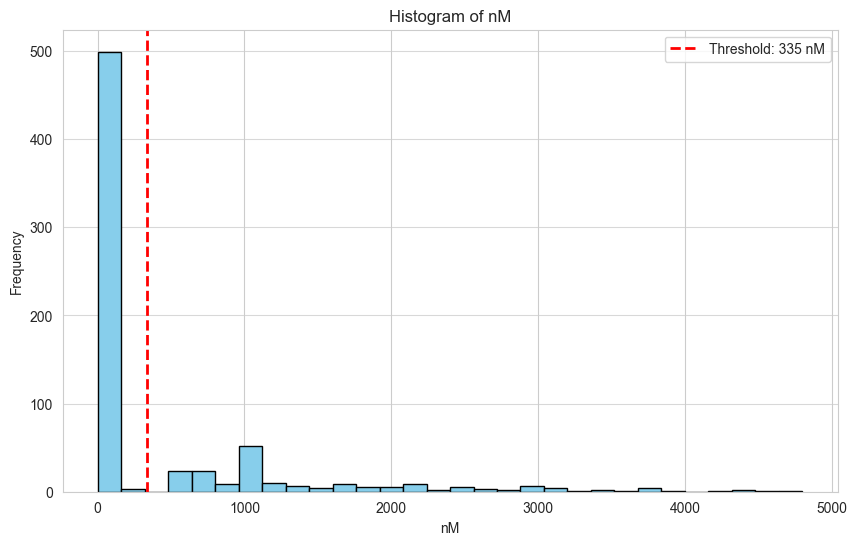

In [6]:
plot_column_histogram(df_ready[df_ready["nM"] < 5000], "nM", threshold=335)

And we get quite a balanced dataset - yay!

# AND NOW... WORK FOR ESTÍK

### Feature calculation

In [3]:
# your code here
from source import extract_descriptors
df, descriptors = extract_descriptors(df_ready, smiles_col="Original Smiles")

### TODO - Fingerprints
- EXFP from RDKIT

In [ ]:
# your code here

### TODO - Scaffold extraction

In [7]:
# your code here
# you can use this code as well:

import pandas as pd
from rdkit import Chem
from rdkit.Chem.Scaffolds import MurckoScaffold
from rdkit import RDLogger
from source import get_generic, get_murcko

df['RDKit Mol'] = df['Smiles'].apply(Chem.MolFromSmiles)
df['Scaffold'] = df['RDKit Mol'].apply(get_murcko)
df['Generic Scaffold'] = df['RDKit Mol'].apply(get_generic)
print(df[['Smiles', 'Scaffold', 'Generic Scaffold']].head(5))

                                              Smiles  \
0  CCCCN1C(=O)C(CC(C)C)NC(=O)C12CCN(Cc1ccc(Oc3ccc...   
1  N=C(N)NCCCN[C@H]1CSSC[C@H](C(=O)NCCc2ccc(O)cc2...   
2  N=C(N)NCCC(=O)N[C@H]1CC/C=C\CC[C@H](C(N)=O)NC(...   
3        NCCCCN(Cc1nc2ccccc2[nH]1)[C@H]1CCCc2cccnc21   
4  NCCCCN(C[C@H]1Cc2ccccc2CN1CC(=O)N1CCOCC1)[C@H]...   

                                            Scaffold  \
0      O=C1CNC(=O)C2(CCN(Cc3ccc(Oc4ccccc4)cc3)CC2)N1   
1  O=C1CCSSC[C@H](C(=O)NCCc2ccccc2)NC(=O)[C@H](Cc...   
2  O=C1CCC/C=C\CCCNC(=O)[C@H](Cc2ccc3ccccc3c2)NC(...   
3            c1cnc2c(c1)CCC[C@@H]2NCc1nc2ccccc2[nH]1   
4  O=C(CN1Cc2ccccc2C[C@@H]1CN[C@H]1CCCc2cccnc21)N...   

                                    Generic Scaffold  
0        CC1CCC(C)C2(CCC(CC3CCC(CC4CCCCC4)CC3)CC2)C1  
1  CC1CCCCCC(C(C)CCCC2CCCCC2)CC(C)C(CC2CCC3CCCCC3...  
2         CC1CCCCCCCCCC(C)C(CC2CCC3CCCCC3C2)CC(C)CC1  
3                    C1CCC2CC(CCC3CCCC4CCCCC43)CC2C1  
4        CC(CC1CC2CCCCC2CC1CCC1CCCC2CCCCC21)C1CCCCC

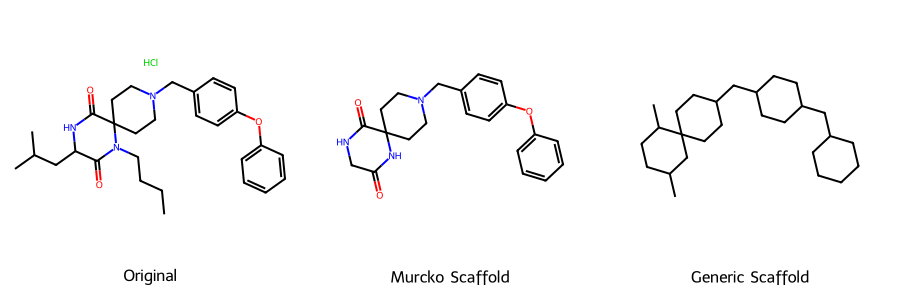

In [8]:
from source import draw_scaffold_comparison

draw_scaffold_comparison(df, 0)

### TODO - distance for TSNE?
Here I am not sure what exactly we need for input to tsne.
- ideally Jaccard

In [ ]:
# your code here

### TODO - TSNE
- ideally create three TSNE:
    - one with all the features (descriptors)
    - one only with the fingerprints
    - one only with the scaffolds (or maybe only the generic scaffolds)

In [ ]:
# your code here

### ML

In [13]:
from train_model import prepare_data, train_RF, evaluate_model, train_KNN, train_logistic_regression, train_ridge_logistic

train_X, train_y, test_X, test_y = prepare_data(df, target_col='Inhibitor', feature_cols=descriptors)
trained_model = train_RF(train_X, train_y)
evaluate_model(trained_model, test_X, test_y)

Best Parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}
Final Model Accuracy: 0.8200
------------------------------
Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.78      0.81       100
           1       0.80      0.86      0.83       100

    accuracy                           0.82       200
   macro avg       0.82      0.82      0.82       200
weighted avg       0.82      0.82      0.82       200



In [12]:
trained_model = train_KNN(train_X, train_y)
evaluate_model(trained_model, test_X, test_y)

Best Parameters: {'n_neighbors': 1}
Final Model Accuracy: 0.7700
------------------------------
Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.76      0.77       100
           1       0.76      0.78      0.77       100

    accuracy                           0.77       200
   macro avg       0.77      0.77      0.77       200
weighted avg       0.77      0.77      0.77       200



In [11]:
trained_model = train_logistic_regression(train_X, train_y)
evaluate_model(trained_model, test_X, test_y)

Best Parameters: {'lr__C': 10, 'lr__l1_ratio': 1}
Final Model Accuracy: 0.7500
------------------------------
Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.81      0.76       100
           1       0.78      0.69      0.73       100

    accuracy                           0.75       200
   macro avg       0.75      0.75      0.75       200
weighted avg       0.75      0.75      0.75       200



In [10]:
trained_model = train_ridge_logistic(train_X, train_y)
evaluate_model(trained_model, test_X, test_y)

Best Parameters: {'lr__C': 10}
Final Model Accuracy: 0.7250
------------------------------
Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.77      0.74       100
           1       0.75      0.68      0.71       100

    accuracy                           0.72       200
   macro avg       0.73      0.73      0.72       200
weighted avg       0.73      0.72      0.72       200

